# Yb High-Fidelity Point-Count Split Test

(a) Construct the initial lower-bound square-grid dataset for the emulator point-count study.

For the 225-point Yb grid, this notebook starts from the centered 9x9 square, then keeps a ~55/45 train/test split within that selected square. If the split fraction is non-integer, the training count is rounded to the nearest integer. Later sweeps can increase the square side length while preserving complete square grids.

## Setup

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "Dipole_polarizability").exists() and ROOT.name == "tests":
    ROOT = ROOT.parent
if not (ROOT / "Dipole_polarizability").exists():
    raise RuntimeError("Run this notebook from the SMLR repository root or from SMLR/tests.")

sys.path.insert(0, str(ROOT / "Dipole_polarizability" / "src"))
sys.path.insert(0, str(ROOT / "src"))

import helper_gpt  # noqa: E402

plt.rcParams.update({"figure.dpi": 140, "axes.grid": True})
print("Repository root:", ROOT)
print("Using helper:", Path(helper_gpt.__file__).resolve())

Repository root: /Users/laurenjin/Documents/projects/SMLR-tests/SMLR
Using helper: /Users/laurenjin/Documents/projects/SMLR-tests/SMLR/Dipole_polarizability/src/helper_gpt.py


## Configuration

In [11]:
# Initial lower-bound square requested for step a.
SQUARE_SIDE = 9
SQUARE_SIDES_FOR_LATER_SWEEP = [9, 10, 11, 12, 13, 14, 15]
TOTAL_POINTS = SQUARE_SIDE ** 2
TRAIN_FRACTION = 0.55

# The known upper-bound training box from the 225-point study.
UPPER_BOUND_TRAIN_FILTER = {"p1": [0.4, 1.8], "p2": [1.5, 4.0]}

STRENGTH_DIR = ROOT / "dipole_polarizability_160Yb" / "total_strength"
ALPHAD_DIR = ROOT / "dipole_polarizability_160Yb" / "total_alphaD"
SPLIT_DIR = ROOT / "tests" / "splits" / f"yb_square_{SQUARE_SIDE}x{SQUARE_SIDE}"
SPLIT_DIR.mkdir(parents=True, exist_ok=True)

print("Split output:", SPLIT_DIR)

Split output: /Users/laurenjin/Documents/projects/SMLR-tests/SMLR/tests/splits/yb_square_9x9


## Load The Full 225-Point Grid

In [12]:
dataset = helper_gpt.load_dataset(
    strength_dir=str(STRENGTH_DIR),
    alphaD_dir=str(ALPHAD_DIR),
    strength_regex=r"strength_(?P<p2>[0-9.]+)_(?P<p1>[0-9.]+)\.out",
)

param_df = pd.DataFrame(dataset.param_values, columns=dataset.param_names)
param_df["sample_index"] = np.arange(len(param_df))
param_df["sample_id"] = ["_".join(x) for x in dataset.sample_ids]

axes_values = {name: np.sort(param_df[name].unique()) for name in dataset.param_names}
print(f"Loaded {len(param_df)} total points.")
print("Parameter names:", dataset.param_names)
for name, values in axes_values.items():
    print(f"{name}: {len(values)} values from {values[0]:.4g} to {values[-1]:.4g}")
display(param_df[dataset.param_names].describe())

Loaded 225 total points.
Parameter names: ['p1', 'p2']
p1: 15 values from 0.2 to 2
p2: 15 values from 1 to 4.5


,p1,p2
count,225.000000,225.000000
mean,1.100000,2.750000
std,0.556669,1.082532
min,0.200000,1.000000
25%,0.586000,1.750000
50%,1.100000,2.750000
75%,1.614000,3.750000
max,2.000000,4.500000


## Build The Centered 9x9 Split

The selected set is a complete centered square in the original 15x15 grid. For `SQUARE_SIDE = 9`, this gives 81 total points. The training set contains `round(0.55 * 81) = 45` points, chosen from the selected square by nearest-center ordering; the remaining 36 selected points are the test set.

In [13]:
def centered_axis_values(values: np.ndarray, side: int) -> np.ndarray:
    values = np.sort(np.asarray(values))
    if side > len(values):
        raise ValueError(f"Requested side={side}, but axis only has {len(values)} values.")
    if side % 2 != 1:
        raise ValueError("Use odd square sides so the selected square is centered on a grid point.")
    center_idx = len(values) // 2
    half = side // 2
    return values[center_idx - half : center_idx + half + 1]


def add_center_ordering(df: pd.DataFrame, param_names: list[str]) -> pd.DataFrame:
    out = df.copy()
    scaled_cols = []
    for name in param_names:
        values = np.sort(out[name].unique())
        center = 0.5 * (values.min() + values.max())
        step = float(np.median(np.diff(values))) if len(values) > 1 else 1.0
        col = f"{name}_grid_offset"
        out[col] = (out[name] - center) / step
        scaled_cols.append(col)

    offsets = out[scaled_cols].to_numpy(float)
    out["chebyshev_radius"] = np.max(np.abs(offsets), axis=1)
    out["euclidean_radius"] = np.sqrt(np.sum(offsets ** 2, axis=1))
    out["manhattan_radius"] = np.sum(np.abs(offsets), axis=1)
    return out.sort_values(
        ["euclidean_radius", "chebyshev_radius", "manhattan_radius", *param_names],
        kind="mergesort",
    ).reset_index(drop=True)


def make_square_split(df: pd.DataFrame, square_side: int, train_fraction: float) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, dict]:
    if not 0 < train_fraction < 1:
        raise ValueError("train_fraction must be between 0 and 1.")
    axis_selection = {
        name: centered_axis_values(df[name].unique(), int(square_side))
        for name in dataset.param_names
    }
    selected_mask = np.ones(len(df), dtype=bool)
    for name, values in axis_selection.items():
        selected_mask &= df[name].isin(values).to_numpy()
    selected = add_center_ordering(df[selected_mask], dataset.param_names).copy()
    expected_total = int(square_side) ** 2
    if len(selected) != expected_total:
        raise RuntimeError(f"Expected {expected_total} selected points, got {len(selected)}.")
    train_count = int(round(train_fraction * len(selected)))
    selected["split"] = "test"
    selected.iloc[:train_count, selected.columns.get_loc("split")] = "train"
    train = selected[selected["split"] == "train"].copy()
    test = selected[selected["split"] == "test"].copy()
    selection_info = {
        name: [float(values.min()), float(values.max()), int(len(values))]
        for name, values in axis_selection.items()
    }
    return selected, train, test, selection_info


selected_df, train_df, test_df, square_axis_selection = make_square_split(param_df, SQUARE_SIDE, TRAIN_FRACTION)

print(f"Selected square: {SQUARE_SIDE}x{SQUARE_SIDE} = {len(selected_df)} points")
print(f"Train/test: {len(train_df)}/{len(test_df)}")
display(selected_df[dataset.param_names + ["split", "sample_index", "sample_id", "euclidean_radius", "chebyshev_radius"]].head(10))

sweep_plan = pd.DataFrame({
    "square_side": SQUARE_SIDES_FOR_LATER_SWEEP,
    "total_points": [side ** 2 for side in SQUARE_SIDES_FOR_LATER_SWEEP],
    "train_points": [int(round(TRAIN_FRACTION * side ** 2)) for side in SQUARE_SIDES_FOR_LATER_SWEEP],
})
sweep_plan["test_points"] = sweep_plan["total_points"] - sweep_plan["train_points"]
display(sweep_plan)

Selected square: 9x9 = 81 points
Train/test: 45/36


,p1,p2,split,sample_index,sample_id,euclidean_radius,chebyshev_radius
0,1.100,2.75,train,112,1.1000_2.7500,0.000000,0.000000
1,1.100,2.50,train,97,1.1000_2.5000,1.000000,1.000000
2,1.100,3.00,train,127,1.1000_3.0000,1.000000,1.000000
3,1.229,2.75,train,113,1.2290_2.7500,1.003891,1.003891
4,0.971,2.75,train,111,0.9710_2.7500,1.003891,1.003891
5,1.229,2.50,train,98,1.2290_2.5000,1.416967,1.003891
6,1.229,3.00,train,128,1.2290_3.0000,1.416967,1.003891
7,0.971,2.50,train,96,0.9710_2.5000,1.416968,1.003891
8,0.971,3.00,train,126,0.9710_3.0000,1.416968,1.003891
9,1.100,2.25,train,82,1.1000_2.2500,2.000000,2.000000


,square_side,total_points,train_points,test_points
0,9,81,45,36
1,10,100,55,45
2,11,121,67,54
3,12,144,79,65
4,13,169,93,76
5,14,196,108,88
6,15,225,124,101


## Training And Testing Ranges

In [15]:
def range_summary(df: pd.DataFrame, label: str) -> dict:
    row = {"label": label, "count": int(len(df))}
    for name in dataset.param_names:
        row[f"{name}_min"] = float(df[name].min())
        row[f"{name}_max"] = float(df[name].max())
        row[f"{name}_n_unique"] = int(df[name].nunique())
    return row


range_table = pd.DataFrame([
    range_summary(param_df, "full_225"),
    range_summary(selected_df, f"selected_{SQUARE_SIDE}x{SQUARE_SIDE}"),
    range_summary(train_df, "train"),
    range_summary(test_df, "test"),
])
display(range_table)

train_filter_box = {
    name: [float(train_df[name].min()), float(train_df[name].max())]
    for name in dataset.param_names
}
selected_filter_box = {
    name: [float(selected_df[name].min()), float(selected_df[name].max())]
    for name in dataset.param_names
}

print(f"Bounding box for the selected {SQUARE_SIDE}x{SQUARE_SIDE} square:")
print(json.dumps(selected_filter_box, indent=2))
print(f"Bounding box for the {len(train_df)}-point training set:")
print(json.dumps(train_filter_box, indent=2))
print("Reference upper-bound train filter:")
print(json.dumps(UPPER_BOUND_TRAIN_FILTER, indent=2))

,label,count,p1_min,p1_max,p1_n_unique,p2_min,p2_max,p2_n_unique
0,full_225,225,0.200,2.000,15,1.00,4.50,15
1,selected_9x9,81,0.586,1.614,9,1.75,3.75,9
2,train,45,0.714,1.486,7,2.00,3.50,7
3,test,36,0.586,1.614,9,1.75,3.75,9


Bounding box for the selected 9x9 square:
{
  "p1": [
    0.5860000252723694,
    1.6139999628067017
  ],
  "p2": [
    1.75,
    3.75
  ]
}
Bounding box for the 45-point training set:
{
  "p1": [
    0.7139999866485596,
    1.4859999418258667
  ],
  "p2": [
    2.0,
    3.5
  ]
}
Reference upper-bound train filter:
{
  "p1": [
    0.4,
    1.8
  ],
  "p2": [
    1.5,
    4.0
  ]
}


## Visual Audit

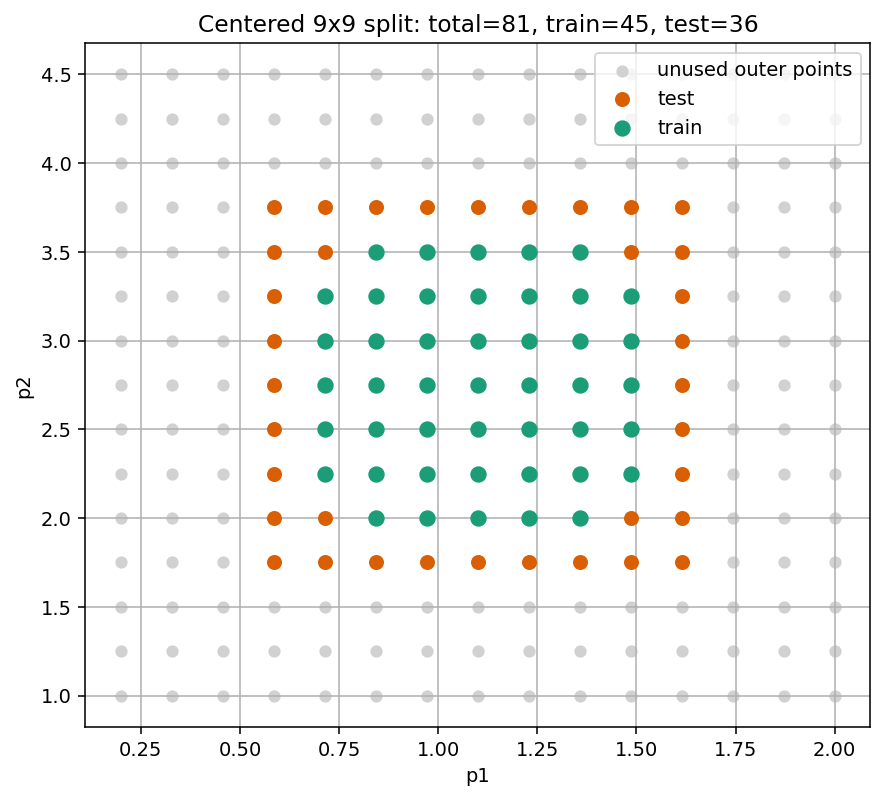

In [16]:
fig, ax = plt.subplots(figsize=(6.2, 5.6), constrained_layout=True)

outside = param_df.merge(selected_df[["sample_index", "split"]], on="sample_index", how="left")
outside["split"] = outside["split"].fillna("unused")

styles = {
    "unused": dict(color="0.82", s=28, label="unused outer points", zorder=1),
    "test": dict(color="#d95f02", s=45, label="test", zorder=3),
    "train": dict(color="#1b9e77", s=55, label="train", zorder=4),
}
for split, style in styles.items():
    sub = outside[outside["split"] == split]
    ax.scatter(sub["p1"], sub["p2"], **style)

ax.set_xlabel("p1")
ax.set_ylabel("p2")
ax.set_title(f"Centered {SQUARE_SIDE}x{SQUARE_SIDE} split: total={len(selected_df)}, train={len(train_df)}, test={len(test_df)}")
ax.legend(loc="best")
ax.set_aspect("auto")
plt.show()

## Save Split Manifests

In [17]:
manifest_cols = dataset.param_names + ["sample_index", "sample_id", "split", "euclidean_radius", "chebyshev_radius"]

selected_df[manifest_cols].sort_values(["split", *dataset.param_names]).to_csv(SPLIT_DIR / "selected_points.csv", index=False)
train_df[dataset.param_names].to_csv(SPLIT_DIR / "train_param_values.csv", index=False)
test_df[dataset.param_names].to_csv(SPLIT_DIR / "test_param_values.csv", index=False)
np.savetxt(SPLIT_DIR / "train_param_values.txt", train_df[dataset.param_names].to_numpy(float))
np.savetxt(SPLIT_DIR / "test_param_values.txt", test_df[dataset.param_names].to_numpy(float))

summary = {
    "total_available_points": int(len(param_df)),
    "square_side": int(SQUARE_SIDE),
    "square_sides_for_later_sweep": [int(x) for x in SQUARE_SIDES_FOR_LATER_SWEEP],
    "selected_total_points": int(len(selected_df)),
    "train_points": int(len(train_df)),
    "test_points": int(len(test_df)),
    "train_fraction_requested": float(TRAIN_FRACTION),
    "train_fraction_actual": float(len(train_df) / len(selected_df)),
    "selection_rule": "complete centered square in parameter grid; train subset chosen by nearest-center order within selected square",
    "square_axis_selection": square_axis_selection,
    "selected_filter_box": selected_filter_box,
    "train_filter_box": train_filter_box,
    "upper_bound_train_filter_reference": UPPER_BOUND_TRAIN_FILTER,
}
with open(SPLIT_DIR / "split_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Saved:")
for path in sorted(SPLIT_DIR.iterdir()):
    print(" ", path.relative_to(ROOT))

Saved:
  tests/splits/yb_square_9x9/selected_points.csv
  tests/splits/yb_square_9x9/split_summary.json
  tests/splits/yb_square_9x9/test_param_values.csv
  tests/splits/yb_square_9x9/test_param_values.txt
  tests/splits/yb_square_9x9/train_param_values.csv
  tests/splits/yb_square_9x9/train_param_values.txt


## Next Metrics To Track In Step b

When the emulator sweep is added, record at least these per-count metrics for both train and test sets:

- Strength reconstruction: global RMSE, median per-spectrum RMSE, p90 per-spectrum RMSE, relative integrated L2 error.
- Observable: mean/median/p90 alphaD relative error.
- Generalization gap: test metric divided by train metric for strength and alphaD.
- Optimization stability: best cost, seed, best iteration, and cost-history tail slope.
- Coverage metadata: total/train/test counts, train/test bounding boxes, and selected-set bounding box.